# Imports

In [19]:
import pandas as pd
import numpy as np

# Get and Format Data

In [20]:
def prepare_data(data, year):
    data = data.rename(columns=lambda x: x[2:] if x[1]=='_' else x)
    data['year'] = year
    data = data.sample(frac=1)
    return data

In [21]:
amazon_train_sets = [prepare_data(pd.read_csv(f"datasets/post_pivot/plus_one/expanded_class/types/tropical/amazon_train_{year}.csv"), year) for year in range(2022, 2025)]
amazon_train = pd.concat(amazon_train_sets, axis=0)

borneo_train_sets = [prepare_data(pd.read_csv(f"datasets/post_pivot/plus_one/expanded_class/types/tropical/borneo_train_{year}.csv"), year) for year in range(2022, 2025)]
borneo_train = pd.concat(borneo_train_sets, axis=0)

congo_train_sets = [prepare_data(pd.read_csv(f"datasets/post_pivot/plus_one/expanded_class/types/tropical/congo_train_{year}.csv"), year) for year in range(2022, 2025)]
congo_train = pd.concat(congo_train_sets, axis=0)

train_set = pd.concat([amazon_train, borneo_train, congo_train], axis=0)
train_set = train_set.sample(frac=1)
train_set = train_set.sort_values(by='year')
print(train_set.head())
# print(train_set.groupby('year')['class'].count())

     system:index  NBR_delta_lag4  NBR_lag4  NDMI_delta_lag4  NDMI_lag4  \
5147     2_2147_0       -0.015784  0.336073        -0.016208   0.197924   
1490     1_4501_0        0.054675  0.324446         0.059683   0.226012   
4321     2_1382_0        0.081372  0.341845         0.050673   0.224816   
1959     1_4975_0        0.120677  0.360077         0.126510   0.243063   
3020       2_20_0       -0.011449  0.345747        -0.008799   0.213979   

      NDVI_delta_lag4  NDVI_lag4  SR_B4_delta_lag4  SR_B4_lag4  \
5147        -0.014278   0.380337            -158.0      8211.0   
1490         0.061454   0.366414            -482.0      8108.0   
4321         0.091504   0.379152             290.0      7972.0   
1959         0.150353   0.405182           -1192.5      8116.0   
3020        -0.016806   0.390828              86.0      8056.0   

      SR_B5_delta_lag4  ...  NDVI_lag0  SR_B4_lag0  SR_B5_lag0  SR_B6_lag0  \
5147            -989.0  ...   0.394615      8369.0     19279.5     12479.0

In [52]:
print(len(train_set))
print(train_set['year'].sort_values().unique())

53675
[2022 2023 2024]


In [23]:
all_features = train_set.columns.drop(['year', 'system:index', 'class', 'latitude', 'longitude', '.geo', 'year'])

recent_features = ['NBR_delta_lag1', 'NBR_lag1',
       'NDMI_delta_lag1', 'NDMI_lag1', 'NDVI_delta_lag1', 'NDVI_lag1',
       'SR_B4_delta_lag1', 'SR_B4_lag1', 'SR_B5_delta_lag1', 'SR_B5_lag1',
       'SR_B6_delta_lag1', 'SR_B6_lag1', 'SR_B7_delta_lag1', 'SR_B7_lag1',
       'NBR_lag0', 'NDMI_lag0', 'NDVI_lag0', 'SR_B4_lag0', 'SR_B5_lag0',
       'SR_B6_lag0', 'SR_B7_lag0']

In [54]:
from sklearn.model_selection import train_test_split

X = train_set[recent_features]
y = train_set['class']


# Evaluate Model on Training Data via Nested-CV

In [55]:
def custom_year_ts_split(df, year_col):
    """Custom CV splitter for our yearly data."""
    # Get unique years and sort them
    years = sorted(df[year_col].unique())
    
    # We need at least 2 years to do one split (Train Y1 -> Val Y2)
    for i in range(1, len(years)):
        # Training set: All years up to the current split
        train_indices = df[df[year_col].isin(years[:i])].index.values
        
        # Validation set: The very next year
        val_indices = df[df[year_col] == years[i]].index.values
        yield train_indices, val_indices

In [56]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate


In [57]:
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
from xgboost import XGBClassifier

In [58]:
xgboost_param_grid = {
    'model__max_depth': Integer(3, 5),
    'model__min_child_weight': Integer(1, 200),
    'model__subsample': Real(0.7, 1),
    'model__colsample_bylevel': Real(0.5, 1),
    'model__colsample_bynode': Real(0.5, 1),
    'model__reg_lambda': Real(0, 10),
    'model__reg_alpha': Real(0, 10)
}

In [59]:
xgb_pipe = Pipeline([
    ('transformer', PowerTransformer('yeo-johnson')),
    ('model', XGBClassifier(objective='binary:logistic', random_state=1, learning_rate=0.3, tree_method='hist'))
])

tuner = BayesSearchCV(
    estimator=xgb_pipe,
    cv=5,
    n_iter=32,
    refit='f1',
    search_spaces=xgboost_param_grid,
    return_train_score=True,
    random_state=1,
    scoring='f1',
)

cv_iterator = custom_year_ts_split(train_set, 'year')

xgb_results = cross_validate(
    tuner,
    X, 
    y, 
    cv=cv_iterator, 
    scoring=['f1', 'precision', 'recall'], 
    return_estimator=True,
    return_train_score=True  # Crucial for detecting overfitting
)

In [60]:
# Print inner-CV (5-fold) average train/test scores for each outer fold (using best inner params)
for outer_fold, outer_estimator in enumerate(xgb_results['estimator'], start=1):
    search = outer_estimator.named_steps['model'] if hasattr(outer_estimator, "named_steps") else outer_estimator
    inner_results = pd.DataFrame(search.cv_results_)
    best_idx = search.best_index_

    print(f"Outer Fold {outer_fold} Parameters - {search.best_params_}")
    mean_test = inner_results.loc[best_idx, "mean_test_score"]
    std_test = inner_results.loc[best_idx, "std_test_score"]
    print(f"Outer Fold {outer_fold} - Inner Mean Test Score:  {mean_test:.6f}")
    print(f"Outer Fold {outer_fold} - Inner Test Score STD:  {std_test:.6f}")

    if "mean_train_score" in inner_results.columns:
        mean_train = inner_results.loc[best_idx, "mean_train_score"]
        std_train = inner_results.loc[best_idx, "std_train_score"]
        print(f"Outer Fold {outer_fold} - Inner Mean Train Score: {mean_train:.6f}")
        print(f"Outer Fold {outer_fold} - Inner Train Score STD:  {std_test:.6f}")
    else:
        print(f"Outer Fold {outer_fold} - Inner Mean Train Score: not available (set return_train_score=True in BayesSearchCV)")

print('\nOverall Metrics')
print(f"Mean Test f1: {xgb_results['test_f1'].mean():.8f}")
print(f"Mean Test Precision: {xgb_results['test_precision'].mean():.8f}")
print(f"Mean Test Recall: {xgb_results['test_recall'].mean():.8f}")

print(f"Mean Train f1: {xgb_results['train_f1'].mean():.8f}")
print(f"Mean Train Precision: {xgb_results['train_precision'].mean():.8f}")
print(f"Mean Train Recall: {xgb_results['train_recall'].mean():.8f}")

print(f"Overfitting Ratio: {1-xgb_results['test_f1'].mean()/xgb_results['train_f1'].mean()}")

Outer Fold 1 Parameters - OrderedDict({'model__colsample_bylevel': 1.0, 'model__colsample_bynode': 1.0, 'model__max_depth': 5, 'model__min_child_weight': 1, 'model__reg_alpha': 0.0, 'model__reg_lambda': 0.0, 'model__subsample': 1.0})
Outer Fold 1 - Inner Mean Test Score:  0.975425
Outer Fold 1 - Inner Test Score STD:  0.002734
Outer Fold 1 - Inner Mean Train Score: 0.994266
Outer Fold 1 - Inner Train Score STD:  0.002734
Outer Fold 2 Parameters - OrderedDict({'model__colsample_bylevel': 1.0, 'model__colsample_bynode': 1.0, 'model__max_depth': 5, 'model__min_child_weight': 1, 'model__reg_alpha': 0.0, 'model__reg_lambda': 0.0, 'model__subsample': 0.7})
Outer Fold 2 - Inner Mean Test Score:  0.993539
Outer Fold 2 - Inner Test Score STD:  0.000630
Outer Fold 2 - Inner Mean Train Score: 0.996485
Outer Fold 2 - Inner Train Score STD:  0.000630

Overall Metrics
Mean Test f1: 0.99504292
Mean Test Precision: 0.99921616
Mean Test Recall: 0.99090855
Mean Train f1: 0.99504428
Mean Train Precision:

In [ ]:
import shap
# Re-fit the tuner on full training data to get a final best estimator for interpretation
tuner.fit(X, y)
best_pipe = tuner.best_estimator_
model = best_pipe.named_steps['model']
explainer = shap.Explainer(model)
# Transform training data for the model component
X_trans = pd.DataFrame(
    best_pipe.named_steps['transformer'].transform(X),
    columns=recent_features,
    index=X.index,
)
shap_values = explainer(X_trans)
# visualize explanations
shap.plots.beeswarm(shap_values)
shap.plots.bar(shap_values)


TypeError: DataFrame.__init__() got an unexpected keyword argument 'verbose'

# Train Model

In [62]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=1)

In [63]:
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
from xgboost import XGBClassifier
from sklearn.preprocessing import PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score

In [64]:
xgboost_param_grid = {
    'model__max_depth': Integer(3, 5),
    'model__min_child_weight': Integer (1, 200),
    'model__subsample': Real(0.7, 1),
    'model__colsample_bylevel': Real(0.5, 1),
    'model__colsample_bynode': Real(0.5, 1),
    'model__reg_lambda': Real(0, 10),
    'model__reg_alpha': Real(0, 10)
}

In [65]:
stage_1_pipe = Pipeline([
    ('transformer', PowerTransformer('yeo-johnson')),
    ('model', XGBClassifier(objective='binary:logistic', random_state=1, learning_rate=0.3, tree_method='hist'))])

tuner = BayesSearchCV(
    estimator=stage_1_pipe,
    cv=5,
    refit='f1',
    search_spaces=xgboost_param_grid,
    return_train_score=True,
    random_state=1,
    scoring='f1'
)

In [66]:
tuner.fit(X_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,search_spaces,"{'model__colsample_bylevel': Real(low=0.5,...m='normalize'), 'model__colsample_bynode': Real(low=0.5,...m='normalize'), 'model__max_depth': Integer(low=3...m='normalize'), 'model__min_child_weight': Integer(low=1...m='normalize'), ...}"
,optimizer_kwargs,None
,n_iter,50
,scoring,'f1'
,fit_params,None
,n_jobs,1
,n_points,1
,iid,'deprecated'
,refit,'f1'
,cv,5


In [67]:
print(tuner.best_params_)
params = {k.replace('model__', ''): v for k, v in tuner.best_params_.items()}


OrderedDict({'model__colsample_bylevel': 0.915199506103644, 'model__colsample_bynode': 0.5067245252545651, 'model__max_depth': 5, 'model__min_child_weight': 57, 'model__reg_alpha': 4.479524141176995, 'model__reg_lambda': 6.897676461199844, 'model__subsample': 0.9060579790562104})


In [68]:
stage_2_transformer = PowerTransformer('yeo-johnson')
stage_2_model = XGBClassifier(**params, objective='binary:logistic', random_state=1, learning_rate=0.001, early_stopping_rounds=50, eval_metric="logloss", tree_method='hist')

In [69]:
X_train_stage2 = stage_2_transformer.fit_transform(X_train)
X_val_stage2 = stage_2_transformer.transform(X_val)

stage_2_model.fit(
    X_train_stage2, y_train,
    eval_set=[(X_val_stage2, y_val)], # Required for early stopping
    verbose=True,                     # Shows progress
)

[0]	validation_0-logloss:0.69259
[1]	validation_0-logloss:0.69203
[2]	validation_0-logloss:0.69148
[3]	validation_0-logloss:0.69092
[4]	validation_0-logloss:0.69037
[5]	validation_0-logloss:0.68983
[6]	validation_0-logloss:0.68928
[7]	validation_0-logloss:0.68873
[8]	validation_0-logloss:0.68818
[9]	validation_0-logloss:0.68763
[10]	validation_0-logloss:0.68709
[11]	validation_0-logloss:0.68654
[12]	validation_0-logloss:0.68600
[13]	validation_0-logloss:0.68545
[14]	validation_0-logloss:0.68491
[15]	validation_0-logloss:0.68436
[16]	validation_0-logloss:0.68382
[17]	validation_0-logloss:0.68328
[18]	validation_0-logloss:0.68275
[19]	validation_0-logloss:0.68221
[20]	validation_0-logloss:0.68167
[21]	validation_0-logloss:0.68114
[22]	validation_0-logloss:0.68061
[23]	validation_0-logloss:0.68008
[24]	validation_0-logloss:0.67955
[25]	validation_0-logloss:0.67901
[26]	validation_0-logloss:0.67849
[27]	validation_0-logloss:0.67796
[28]	validation_0-logloss:0.67743
[29]	validation_0-loglos

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,0.915199506103644
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,0.5067245252545651
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xg

In [70]:
best_round = stage_2_model.best_iteration
print(best_round)
print(stage_2_model.best_score)


99
0.6423972765789734


In [71]:
final_pipe = Pipeline([
    ('transformer', PowerTransformer('yeo-johnson')),
    ('model', XGBClassifier(**params, objective='binary:logistic', random_state=1, learning_rate=0.001, n_estimators=best_round, tree_method='hist'))])
final_pipe.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('transformer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"method method: {'yeo-johnson', 'box-cox'}, default='yeo-johnson'The power transform method. Available methods are:- 'yeo-johnson' [1]_, works with positive and negative values- 'box-cox' [2]_, only works with strictly positive values",'yeo-johnson'
,"standardize standardize: bool, default=TrueSet to True to apply zero-mean, unit-variance normalization to thetransformed output.",True
,"copy copy: bool, default=TrueSet to False to perform inplace computation during transformation.",True
,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None


In [72]:
print(f1_score(y, final_pipe.predict(X)))

0.8538888997977497


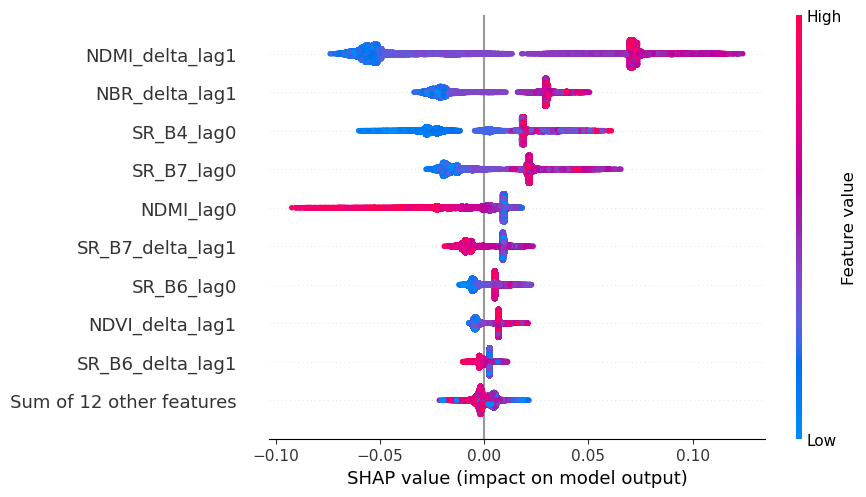

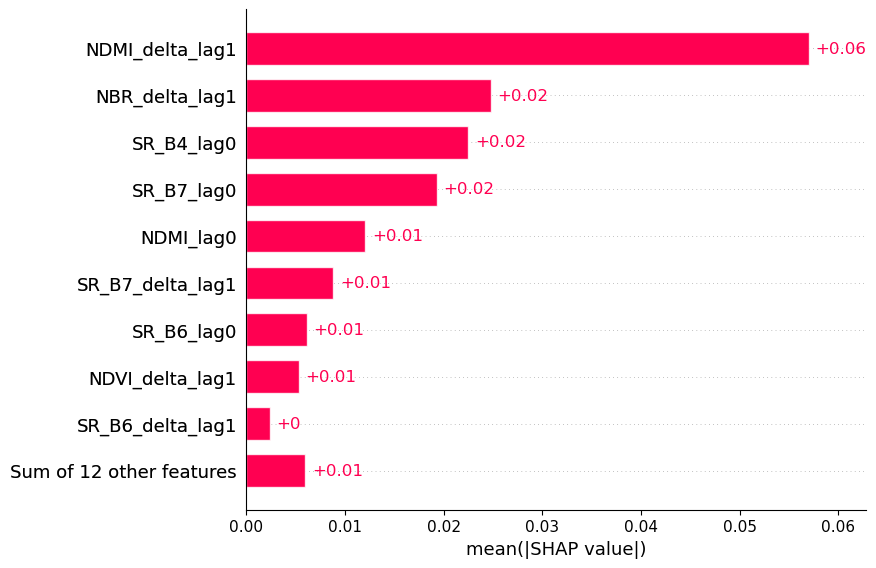

In [73]:
import shap
explainer = shap.Explainer(final_pipe['model'])
# Transform training data for the model component
X_trans = pd.DataFrame(
    final_pipe.named_steps['transformer'].transform(X_train),
    columns=recent_features,
    index=X_train.index,
)
shap_values = explainer(X_trans)
# visualize explanations
shap.plots.beeswarm(shap_values)
shap.plots.bar(shap_values)


In [74]:
print(len(X))

53675


# Test On Holdout Set From the Same Region

In [75]:
amazon_test = prepare_data(pd.read_csv(f"datasets/post_pivot/plus_one/expanded_class/types/tropical/amazon_test_2025.csv"), 2025)
borneo_test = prepare_data(pd.read_csv("datasets/post_pivot/plus_one/expanded_class/types/tropical/borneo_test_2025.csv"), 2025)
congo_test = prepare_data(pd.read_csv("datasets/post_pivot/plus_one/expanded_class/types/tropical/congo_test_2025.csv"), 2025)

print(len(amazon_test))
print(len(borneo_test))
print(len(congo_test))
print(congo_test['year'].unique())


6000
5845
6000
[2025]


In [76]:
X_test_amazon = amazon_test[recent_features]
y_test_amazon = amazon_test['class']
X_test_borneo = borneo_test[recent_features]
y_test_borneo = borneo_test['class']
X_test_congo = congo_test[recent_features]
y_test_congo = congo_test['class']
print(y_test_borneo.value_counts())

class
1    2954
0    2891
Name: count, dtype: int64


In [77]:
from sklearn.metrics import precision_score, recall_score

print("Amazon Test")
y_test_amazon_pred = final_pipe.predict(X_test_amazon)
print(f"f1: {f1_score(y_test_amazon, y_test_amazon_pred)}")
print(f"precision: {precision_score(y_test_amazon, y_test_amazon_pred)}")
print(f"recall: {recall_score(y_test_amazon, y_test_amazon_pred)}")

print("Congo Test")
y_test_congo_pred = final_pipe.predict(X_test_congo)
print(f"f1: {f1_score(y_test_congo, y_test_congo_pred)}")
print(f"precision: {precision_score(y_test_congo, y_test_congo_pred)}")
print(f"recall: {recall_score(y_test_congo, y_test_congo_pred)}")

print("Borneo Test")
y_test_borneo_pred = final_pipe.predict(X_test_borneo)
print(f"f1: {f1_score(y_test_borneo, y_test_borneo_pred)}")
print(f"precision: {precision_score(y_test_borneo, y_test_borneo_pred)}")
print(f"recall: {recall_score(y_test_borneo, y_test_borneo_pred)}")

print("All Together Test")
X_test = pd.concat([X_test_amazon, X_test_congo, X_test_borneo])
y_test = pd.concat([y_test_amazon, y_test_congo, y_test_borneo])
y_test_pred = final_pipe.predict(X_test)
print(f"f1: {f1_score(y_test, y_test_pred)}")
print(f"precision: {precision_score(y_test, y_test_pred)}")
print(f"recall: {recall_score(y_test, y_test_pred)}")

Amazon Test
f1: 0.8816901408450705
precision: 0.9343283582089552
recall: 0.8346666666666667
Congo Test
f1: 0.8640314908971626
precision: 0.8505004843396836
recall: 0.878
Borneo Test
f1: 0.8206141138444963
precision: 0.8738049713193117
recall: 0.7735274204468517
All Together Test
f1: 0.8558745532111149
precision: 0.884532888465205
recall: 0.8290149653786018


Models do well!

# Test on New Regions

In [78]:
png_test = prepare_data(pd.read_csv(f"datasets/post_pivot/plus_one/expanded_class/types/tropical/png_test_2025.csv"), 2025)

In [79]:
X_test_png = png_test[recent_features]
y_test_png = png_test['class']
print(y_test_png.value_counts())

class
1    2996
0    2899
Name: count, dtype: int64


In [80]:
print("Papua New Guinea Test")
y_test_png_pred = final_pipe.predict(X_test_png)
print(f"f1: {f1_score(y_test_png, y_test_png_pred)}")
print(f"precision: {precision_score(y_test_png, y_test_png_pred)}")
print(f"recall: {recall_score(y_test_png, y_test_png_pred)}")


Papua New Guinea Test
f1: 0.8119987167147898
precision: 0.7816553428042001
recall: 0.8447930574098799


Tropical model succeeds!